##

## Prelims

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Running on Colab: True
GPU Available:
Thu Jun  4 20:41:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                  

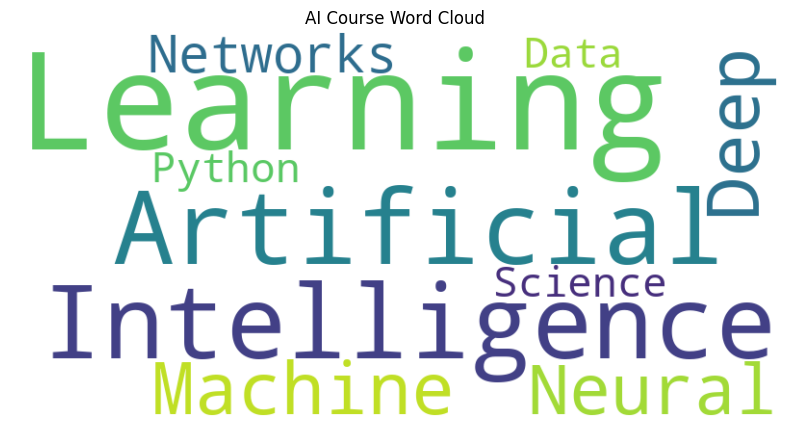

In [1]:
# Lab 0: Colab Practice  Na'ima Mohamet Aloula

# Cell 1: Verify environment
import sys
print(f"Python version: {sys.version}")
print(f"Running on Colab: {'google.colab' in sys.modules}")

# Cell 2: Check GPU
import subprocess
gpu_info = subprocess.run(['nvidia-smi'],
                         capture_output=True, text=True)
if gpu_info.returncode == 0:
    print("GPU Available:")
    print(gpu_info.stdout)
else:
    print("No GPU detected - enable in Runtime > Change runtime type")

# Cell 3: Create a word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = "Artificial Intelligence Machine Learning Deep Learning Neural Networks Python Data Science"
wordcloud = WordCloud(width=800, height=400,
                     background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('AI Course Word Cloud')
plt.show()


## Exercise 4

In [2]:
!mamba install pandas
import numpy as np
import pandas as pd

/bin/bash: line 1: mamba: command not found


In [3]:
# Task 1: 5x5 matrix with border=1 and interior=0
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
print("Task 1 - Border Matrix:")
print(matrix)

Task 1 - Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [4]:
# Task 2: Normalize each column (mean=0, std=1)
np.random.seed(42)
random_data = np.random.randn(100, 3)

col_means = random_data.mean(axis=0)
col_stds = random_data.std(axis=0)
normalized_data = (random_data - col_means) / col_stds

print("\nTask 2 - Normalized Data:")
print("Column means (should be ~0):", normalized_data.mean(axis=0).round(10))
print("Column stds  (should be ~1):", normalized_data.std(axis=0).round(10))


Task 2 - Normalized Data:
Column means (should be ~0): [-0.  0. -0.]
Column stds  (should be ~1): [1. 1. 1.]


In [5]:
# Task 3: Linear Regression using Normal Equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation: theta = (X^T X)^(-1) X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTask 3 - Linear Regression (Normal Equation):")
print("Estimated theta:", np.round(theta_hat, 4))
print("True theta:     ", true_theta)
print("Difference:     ", np.round(np.abs(theta_hat - true_theta), 4))


Task 3 - Linear Regression (Normal Equation):
Estimated theta: [ 2.5172 -1.1978  3.724 ]
True theta:      [ 2.5 -1.2  3.7]
Difference:      [0.0172 0.0022 0.024 ]


In [6]:
np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [7]:
# Task 1: Data Cleaning and Exploration

# Basic info
print("=== Dataset Info ===")
print(df.info())
print("\n=== First 5 rows ===")
print(df.head())

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Fill missing exam_score with mean of same major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median of same year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

=== First 5 rows ===
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486              

In [8]:
# Task 2: Analysis

# Average exam score by major
avg_by_major = df.groupby('major')['exam_score'].mean().round(2)
print("=== Average Exam Score by Major ===")
print(avg_by_major)

# Major with highest average
best_major = avg_by_major.idxmax()
print(f"\nBest Major: {best_major} ({avg_by_major[best_major]:.2f})")

# Correlation
corr = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation (hours_studied vs exam_score): {corr:.4f}")

# Performance column
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print("\n=== Performance Distribution ===")
print(df['performance'].value_counts())

=== Average Exam Score by Major ===
major
Biology    75.50
CS         76.43
Math       74.68
Physics    75.41
Name: exam_score, dtype: float64

Best Major: CS (76.43)

Correlation (hours_studied vs exam_score): -0.0560

=== Performance Distribution ===
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [9]:
# Task 3: Advanced Analysis

# Stats by major and year
print("=== Stats by Major and Year ===")
group_stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(group_stats)

# Top 5 students
print("\n=== Top 5 Students ===")
top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print(top5)

# Pivot table
print("\n=== Pivot Table: Avg Exam Score (Major x Year) ===")
pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print(pivot)

=== Stats by Major and Year ===
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13           76.57              12.68
        2               12           74.90              13.43
        3               14           80.18              14.49
        4               15           70.70              14.25
CS      1               12           77.10              13.04
        2                7           76.16              14.00
        3                9           72.35              15.04
        4               18           78.12              16.28
Math    1               11           74.05              19.00
        2                9           81.23              12.35
        3               10           72.02              15.18
        4               16           73.10              17.42
Physics 1               13           77.83              13.49
        2               12           7

## exercise 5

In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1: Data Cleaning and Exploration

# Basic info
print("=== Dataset Info ===")
print(df.info())
print("\n=== First 5 rows ===")
print(df.head())

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Fill missing exam_score with mean of same major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median of same year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())


# Task 2: Analysis

# Average exam score by major
avg_by_major = df.groupby('major')['exam_score'].mean().round(2)
print("=== Average Exam Score by Major ===")
print(avg_by_major)

# Major with highest average
best_major = avg_by_major.idxmax()
print(f"\nBest Major: {best_major} ({avg_by_major[best_major]:.2f})")

# Correlation
corr = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation (hours_studied vs exam_score): {corr:.4f}")

# Performance column
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print("\n=== Performance Distribution ===")
print(df['performance'].value_counts())


# Task 3: Advanced Analysis

# Stats by major and year
print("=== Stats by Major and Year ===")
group_stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(group_stats)

# Top 5 students
print("\n=== Top 5 Students ===")
top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print(top5)

# Pivot table
print("\n=== Pivot Table: Avg Exam Score (Major x Year) ===")
pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print(pivot)


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

=== First 5 rows ===
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486              

## Exercise 6

Dataset shape: (200, 7)


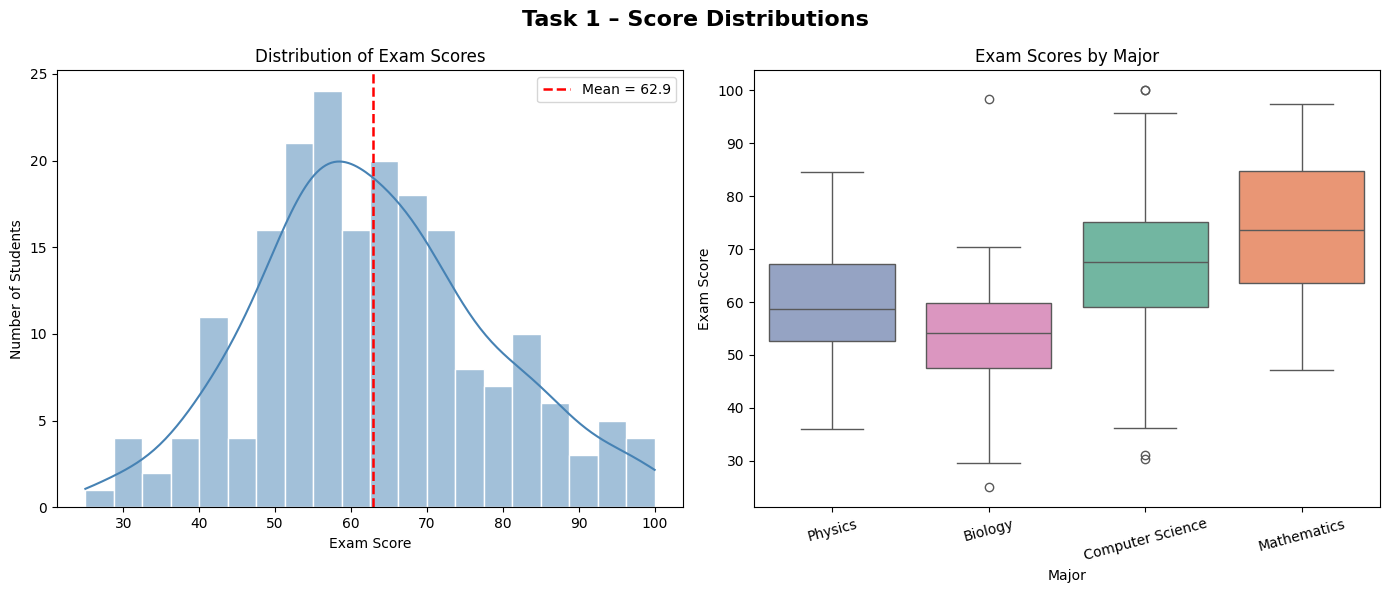

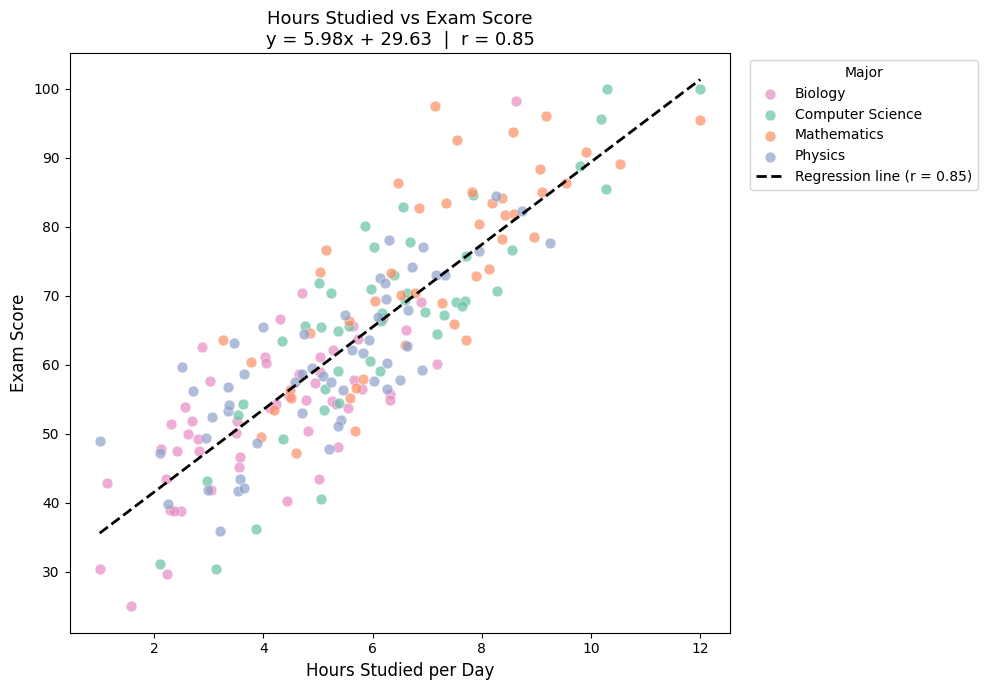

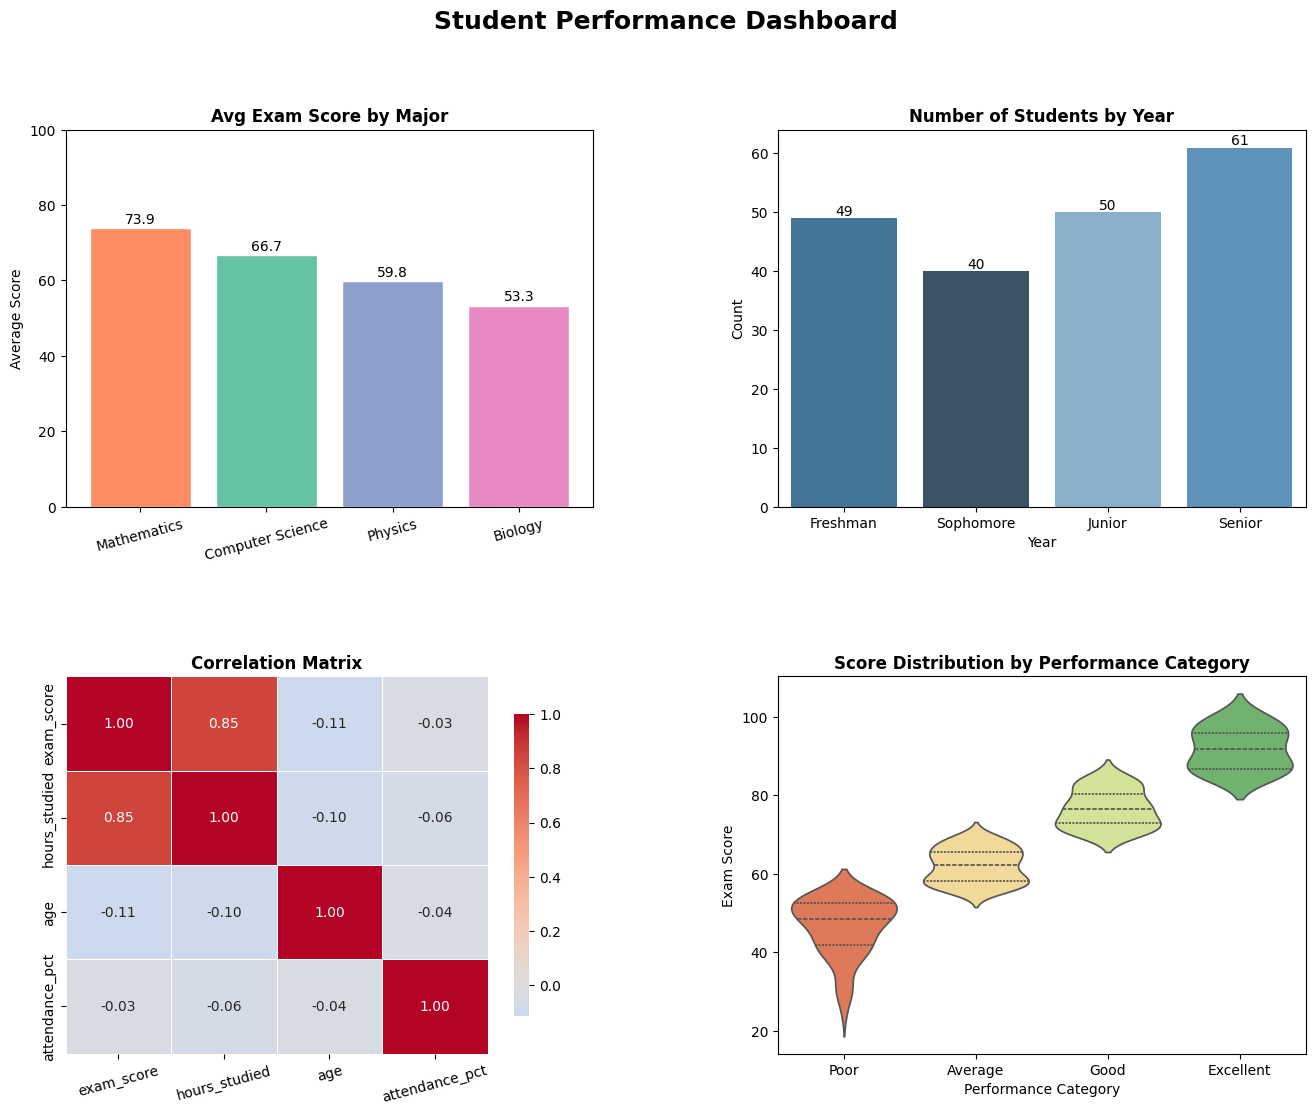

In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

np.random.seed(42)
n = 200
majors = ['Computer Science', 'Mathematics', 'Physics', 'Biology']
years  = ['Freshman', 'Sophomore', 'Junior', 'Senior']

major_col = np.random.choice(majors, n)
year_col  = np.random.choice(years,  n)

major_hours = {
    'Computer Science': (6, 2),
    'Mathematics':      (7, 2),
    'Physics':          (5, 2),
    'Biology':          (4, 2),
}
hours_studied = np.array([
    np.clip(np.random.normal(*major_hours[m]), 1, 12) for m in major_col
])
exam_score = np.clip(hours_studied * 6 + np.random.normal(30, 8, n), 0, 100)

def categorize(score):
    if score >= 85: return 'Excellent'
    if score >= 70: return 'Good'
    if score >= 55: return 'Average'
    return 'Poor'

df = pd.DataFrame({
    'major':          major_col,
    'year':           year_col,
    'hours_studied':  hours_studied,
    'exam_score':     exam_score,
    'performance':    [categorize(s) for s in exam_score],
    'age':            np.random.randint(18, 25, n),
    'attendance_pct': np.clip(np.random.normal(75, 15, n), 0, 100),
})

palette       = sns.color_palette('Set2', len(majors))
major_palette = dict(zip(majors, palette))
perf_order    = ['Poor', 'Average', 'Good', 'Excellent']
perf_palette  = dict(zip(perf_order, sns.color_palette('RdYlGn', 4)))

print(f'Dataset shape: {df.shape}')
df.head()

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('Task 1 – Score Distributions', fontsize=16, fontweight='bold')

# Left: Histogram + KDE
sns.histplot(df['exam_score'], bins=20, kde=True, color='steelblue',
             edgecolor='white', ax=ax1)
ax1.axvline(df['exam_score'].mean(), color='red', linestyle='--', linewidth=1.8,
            label=f"Mean = {df['exam_score'].mean():.1f}")
ax1.set_title('Distribution of Exam Scores')
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Number of Students')
ax1.legend()

# Right: Box plot by major
sns.boxplot(data=df, x='major', y='exam_score',
            hue='major', palette=major_palette, legend=False, ax=ax2)
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(10, 7))

for major, group in df.groupby('major'):
    ax.scatter(group['hours_studied'], group['exam_score'],
               label=major, color=major_palette[major],
               alpha=0.7, s=60, edgecolors='white', linewidths=0.4)

slope, intercept, r, p, _ = stats.linregress(df['hours_studied'], df['exam_score'])
x_line = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=2,
        linestyle='--', label=f'Regression line (r = {r:.2f})')

ax.set_title('Hours Studied vs Exam Score' + chr(10) + f'y = {slope:.2f}x + {intercept:.2f}  |  r = {r:.2f}', fontsize=13)
ax.set_xlabel('Hours Studied per Day', fontsize=12)
ax.set_ylabel('Exam Score', fontsize=12)
ax.legend(title='Major', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
fig3 = plt.figure(figsize=(16, 12))
fig3.suptitle('Student Performance Dashboard', fontsize=18, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig3, hspace=0.45, wspace=0.35)

ax_bar    = fig3.add_subplot(gs[0, 0])
ax_count  = fig3.add_subplot(gs[0, 1])
ax_heat   = fig3.add_subplot(gs[1, 0])
ax_violin = fig3.add_subplot(gs[1, 1])

# 1. Bar chart: Average exam score by major
avg_by_major = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)
bars = ax_bar.bar(avg_by_major.index, avg_by_major.values,
                  color=[major_palette[m] for m in avg_by_major.index],
                  edgecolor='white')
for bar, val in zip(bars, avg_by_major.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
ax_bar.set_title('Avg Exam Score by Major', fontweight='bold')
ax_bar.set_ylabel('Average Score')
ax_bar.set_ylim(0, 100)
ax_bar.tick_params(axis='x', rotation=15)

# 2. Count plot: Students by year
year_order = ['Freshman', 'Sophomore', 'Junior', 'Senior']
sns.countplot(data=df, x='year', order=year_order,
              hue='year', palette='Blues_d', legend=False, ax=ax_count)
for p in ax_count.patches:
    ax_count.annotate(int(p.get_height()),
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha='center', va='bottom', fontsize=10)
ax_count.set_title('Number of Students by Year', fontweight='bold')
ax_count.set_xlabel('Year')
ax_count.set_ylabel('Count')

# 3. Heatmap: Correlation matrix
num_cols = ['exam_score', 'hours_studied', 'age', 'attendance_pct']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax_heat, cbar_kws={'shrink': 0.8})
ax_heat.set_title('Correlation Matrix', fontweight='bold')
ax_heat.tick_params(axis='x', rotation=15)

# 4. Violin plot: Score by performance category
sns.violinplot(data=df, x='performance', y='exam_score',
               hue='performance', order=perf_order, palette=perf_palette,
               inner='quartile', legend=False, ax=ax_violin)
ax_violin.set_title('Score Distribution by Performance Category', fontweight='bold')
ax_violin.set_xlabel('Performance Category')
ax_violin.set_ylabel('Exam Score')

plt.show()


## Exercise 7

Dataset shape: (500, 4)
CLV range:    $0.00 – $1645.71
Average CLV:  $743.76
Age Group Summary:
CLV 90th-percentile threshold : $1222.94
Number of top-10%% customers  : 50
Top customers – avg income    : $47,865
Top customers – avg CLV       : $1,398.89


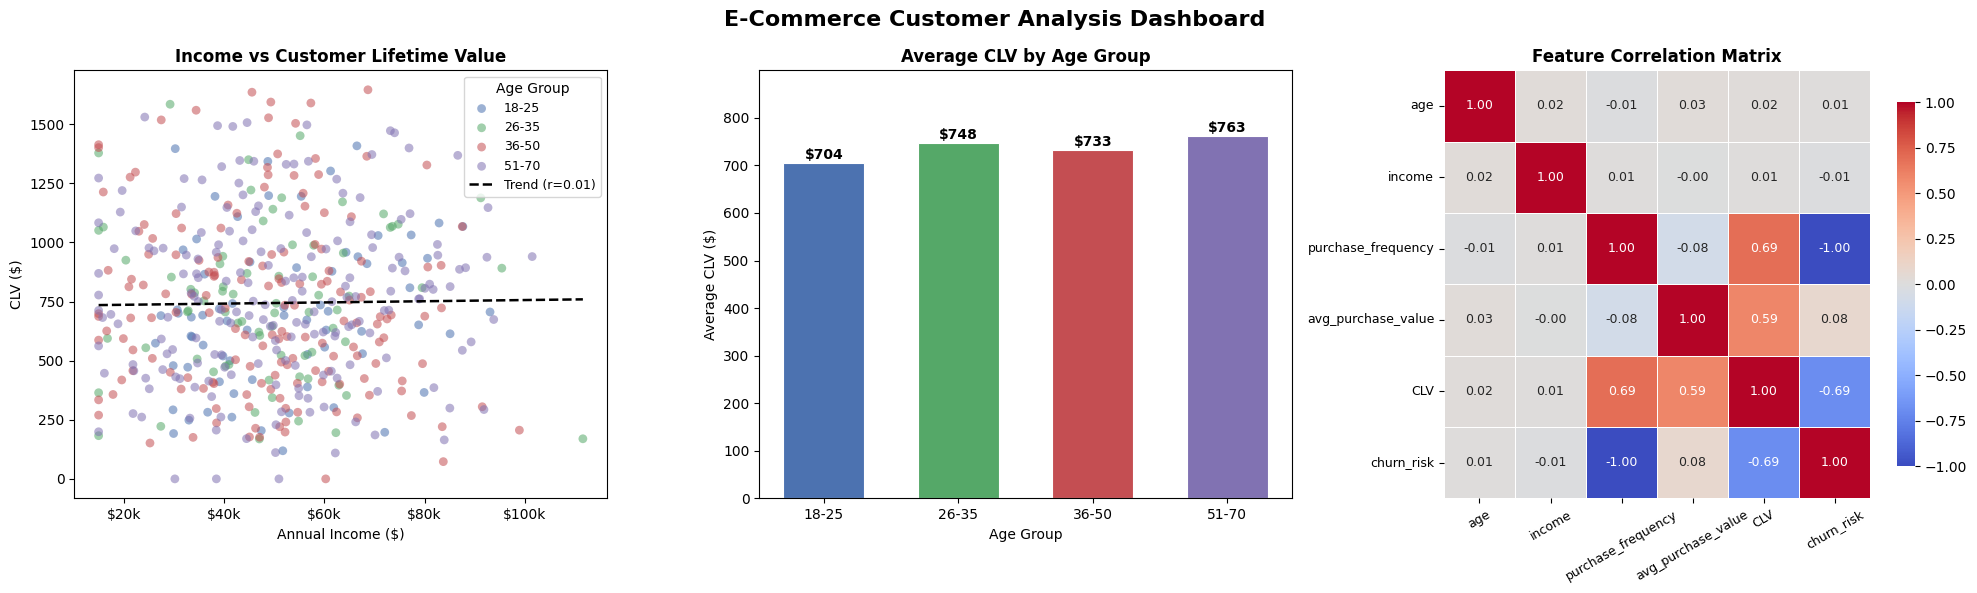

In [12]:
'exercciec 7'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
np.random.seed(42)
n_customers = 500

ages               = np.random.randint(18, 70, n_customers)
income             = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq      = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age':                ages,
    'income':             income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value,
})

print(f'Dataset shape: {customers.shape}')
customers.describe().round(2)
max_frequency = customers['purchase_frequency'].max()

# Churn risk is high when purchase frequency is low
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)

# CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

print(f'CLV range:    ${customers["CLV"].min():.2f} – ${customers["CLV"].max():.2f}')
print(f'Average CLV:  ${customers["CLV"].mean():.2f}')
customers[['purchase_frequency', 'avg_purchase_value', 'churn_risk', 'CLV']].head(8)

bins   = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=True)

age_stats = customers.groupby('age_group', observed=True).agg(
    num_customers = ('CLV',    'count'),
    avg_income    = ('income', 'mean'),
    avg_CLV       = ('CLV',    'mean'),
    total_CLV     = ('CLV',    'sum'),
).round(2)

print('Age Group Summary:')
clv_90th      = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= clv_90th].copy()

print(f'CLV 90th-percentile threshold : ${clv_90th:.2f}')
print(f'Number of top-10%% customers  : {len(top_customers)}')
print(f'Top customers – avg income    : ${top_customers["income"].mean():,.0f}')
print(f'Top customers – avg CLV       : ${top_customers["CLV"].mean():,.2f}')
top_customers.sort_values('CLV', ascending=False).head(10)
ag_palette = {'18-25': '#4C72B0', '26-35': '#55A868', '36-50': '#C44E52', '51-70': '#8172B2'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('E-Commerce Customer Analysis Dashboard', fontsize=16, fontweight='bold')

# ── Plot 1: Income vs CLV scatter (colour by age group)
for group, grp_df in customers.groupby('age_group', observed=True):
    axes[0].scatter(grp_df['income'], grp_df['CLV'],
                    label=str(group), color=ag_palette[str(group)],
                    alpha=0.55, s=40, edgecolors='none')
s, i, r, _, _ = stats.linregress(customers['income'], customers['CLV'])
x_l = np.linspace(customers['income'].min(), customers['income'].max(), 200)
axes[0].plot(x_l, s * x_l + i, color='black', linewidth=1.8,
             linestyle='--', label=f'Trend (r={r:.2f})')
axes[0].set_title('Income vs Customer Lifetime Value', fontweight='bold')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('CLV ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(title='Age Group', fontsize=9)

# ── Plot 2: Average CLV by age group
bars = axes[1].bar(age_stats.index, age_stats['avg_CLV'],
                   color=[ag_palette[str(g)] for g in age_stats.index],
                   edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, age_stats['avg_CLV']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Average CLV by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV ($)')
axes[1].set_ylim(0, age_stats['avg_CLV'].max() * 1.18)

# ── Plot 3: Correlation heatmap
num_cols = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV', 'churn_risk']
corr = customers[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[2], cbar_kws={'shrink': 0.85},
            annot_kws={'size': 9})
axes[2].set_title('Feature Correlation Matrix', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30, labelsize=9)
axes[2].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()
